# 31 · E1r: the 2 × 2 × 2 — which ingredients does the closed level need?

**Where Notebook 30 left off.** Converged, E1's three rules choose **L1s**: sigmoid neurons, per-synapse weights and one global slow current (0.488 held-out FEVE). Seven of the eight combinations of these three ingredients are now fitted:

| held-out FEVE | class weights, fast | class weights, slow | per-synapse weights, fast | per-synapse weights, slow |
|---|---|---|---|---|
| **linear** | L0 0.428 | `L0s` 0.440 | `L0w` 0.429 | **`L0ws` ?** |
| **sigmoid** | `L1c` 0.432 | `L1cs` 0.437 | L1 0.447 | **L1s 0.488** |

Neither the slow current nor the per-synapse weights help much alone; together (L1s) they add +0.056 over `L1c`.

**The missing cell is `L0ws`: linear dynamics, per-synapse weights, slow current** (package 0.26).
* If it matches L1s, the sigmoid is not needed. The closed level is a linear network with measured weights and one slow process, with 142 fewer parameters than L1s.
* If not, all three ingredients are part of the closed level.

**This notebook:**
* fits `L0ws` to convergence (warm-restarted cycles, the same inner split) from two natural starts, keeping the better on validation: the converged `L0w` plus the slow current, and the converged `L0s` plus zero per-synapse deviations;
* analyses the full 2 × 2 × 2 as a factorial, with main effects and interactions;
* applies E1's rules a last time to the complete ladder.

It closes E1.

In [1]:
#@title Setup — run first (works locally on a Mac/PC and on Colab)
import os, sys, subprocess
REPO_URL   = "https://github.com/aslansd/Closure-Bench.git"  # Colab only: clone from here
DRIVE_PATH = "/content/drive/MyDrive/Closure-Bench"          # Colab only: ...or use a Drive copy
IN_COLAB = "google.colab" in sys.modules

def _find_package():
    # 1) explicit location, 2) the repo this notebook lives in, 3) Colab clone / Drive
    cands = [os.environ.get("CLOSUREBENCH_ROOT", ""), ".", "..", "/content/Closure-Bench", DRIVE_PATH]
    for root in cands:
        if root and os.path.isdir(os.path.join(root, "closurebench")):
            return os.path.abspath(root)
    if IN_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wormneuroatlas", "optax"], check=False)
        if subprocess.run(["git", "clone", "-q", REPO_URL, "/content/Closure-Bench"]).returncode == 0:
            return "/content/Closure-Bench"
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.isdir(os.path.join(DRIVE_PATH, "closurebench")):
            return DRIVE_PATH
    raise RuntimeError("closurebench not found. Locally: open this notebook from Closure-Bench/notebooks/, "
                       "or set the environment variable CLOSUREBENCH_ROOT to the Closure-Bench folder.")

ROOT = _find_package()
sys.path.insert(0, ROOT)
try:
    import jax, optax, wormneuroatlas  # noqa: F401
except ImportError as e:
    raise ImportError(f"{e}. Locally, create the environment first: see README.md "
                      "('Run locally'), then select the 'Python (closurebench)' kernel.") from None
RESULTS = os.environ.get("CLOSUREBENCH_RESULTS", os.path.join(ROOT, "results"))
os.makedirs(RESULTS, exist_ok=True)
from closurebench import config as CBC
MODE = CBC.get_mode()        # 'smoke' | 'laptop' | 'full'  (env CLOSUREBENCH_MODE, default: full on GPU, laptop on CPU)
print("closurebench:", ROOT); print("results:", RESULTS); print(CBC.describe_machine()); print("MODE:", MODE)

closurebench: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac
results: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results
Darwin arm64 | python 3.11.5 | jax 0.10.2 on cpu (cpu) | CPU cores: 8
MODE: laptop


In [2]:
import json, pickle, time, datetime, itertools, numpy as np, matplotlib.pyplot as plt, jax, jax.numpy as jnp
import closurebench
assert tuple(int(x) for x in closurebench.__version__.split(".")[:3]) >= (0, 26, 0), \
    f"Notebook 31 needs closurebench >= 0.26.0 (found {closurebench.__version__}); copy the full package and restart the kernel"
from closurebench import data as D, ladder as lad, metrics as M_
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
N_BOOT, THRESHOLD, VAL_FRAC = 2000, 0.05, 0.2
TAG = "" if MODE == "full" else f"_{MODE}"
E1_TAG = "_laptop" if MODE == "smoke" else TAG
PRIOR = "laptop" if MODE == "smoke" else MODE
CYC = {"smoke": dict(CYCLE_STEPS=30, MAX_CYCLES=3, EVAL_EVERY=10, PATIENCE=2, TOL=1e-3),
       "laptop": dict(CYCLE_STEPS=1000, MAX_CYCLES=6, EVAL_EVERY=100, PATIENCE=5, TOL=1e-3),
       "full": dict(CYCLE_STEPS=1500, MAX_CYCLES=8, EVAL_EVERY=100, PATIENCE=5, TOL=1e-3)}[MODE]; globals().update(CYC)
SLOW_START = (0.1, 10.0)
# the 2 x 2 x 2: (sigmoid?, per-synapse weights?, slow current?) -> rung
CUBE = {(0, 0, 0): "L0", (0, 0, 1): "L0s", (0, 1, 0): "L0w", (0, 1, 1): "L0ws",
        (1, 0, 0): "L1c", (1, 0, 1): "L1cs", (1, 1, 0): "L1", (1, 1, 1): "L1s"}
FACTORS = ("nonlinearity", "synapse weights", "slow current")

def to_np(p):
    q = jax.tree_util.tree_map(np.asarray, dict(p))
    if "n_heads" in q: q["n_heads"] = int(q["n_heads"])
    return q
def to_jnp(p):
    q = {k: (v if k == "n_heads" else jax.tree_util.tree_map(jnp.asarray, v)) for k, v in dict(p).items()}
    if "n_heads" in q: q["n_heads"] = int(q["n_heads"])
    return q

try:
    e1_result = json.load(open(os.path.join(RESULTS, f"E1_result{E1_TAG}.json")))
    c = json.load(open(os.path.join(RESULTS, e1_result["preregistration"])))["config"]
    ds = D.Dataset.load(os.path.join(RESULTS, "atlas_dataset.npz"))
    if c["n_neurons"] < ds.N:
        mk = ds.mask()[0]; score = mk.sum(1).astype(float); score[ds.stim] += mk.sum(0)
        ds = D.subset(ds, np.sort(np.argsort(-score)[:c["n_neurons"]]))
    st = lad.Structure.from_dataset(ds, tie=c["tie_classes"]); cfg = lad.SimConfig(**c["sim"])
    folds = M_.kfold_pairs(ds, c["k_folds"], c["fold_seed"]); LR = float(c.get("lr", 1e-2))
    ck28, ck29, ck30 = (os.path.join(RESULTS, d, PRIOR) for d in ("e1o_ck", "e1p_ck", "e1q_ck"))
    def _load(paths):
        for pth in paths:
            if os.path.exists(pth): return to_np(pickle.load(open(pth, "rb"))["params"])
        raise FileNotFoundError(paths[-1])
    BASE = [{"L0w": _load([os.path.join(ck29, f"fold{f}_L0w_more.pkl"), os.path.join(ck28, f"fold{f}_L0w.pkl")]),
             "L0s": _load([os.path.join(ck30, f"fold{f}_L0s.pkl")])} for f in range(len(folds))]
    PRED = dict(np.load(os.path.join(RESULTS, f"E1p_heldout_predictions{E1_TAG}.npz")))
    PRED.update(dict(np.load(os.path.join(RESULTS, f"E1q_heldout_predictions{E1_TAG}.npz"))))
    d9 = os.path.join(RESULTS, f"E1e_result{E1_TAG}.json")
    DELTA = json.load(open(d9))["delta"] if os.path.exists(d9) else {}
    SOURCE = f"E1 ({E1_TAG.strip('_') or 'full'}) data and folds; converged L0w (28), L0s (30); ladder of Notebooks 29-30"
except (FileNotFoundError, KeyError) as err:
    if MODE != "smoke":
        raise
    print("Notebook 30 results not found (", err, ") -> CODE-PATH TEST ONLY on a synthetic worm")
    ds, p_true, _ = lad.make_synthetic(lad.random_wiring(N=24, S=10, seed=1), true_level="L1", seed=1)
    st = lad.Structure.from_dataset(ds); cfg = lad.SimConfig(); folds = M_.kfold_pairs(ds, 2, 0); LR = 1e-2
    BASE = PRED = None; DELTA = {"repeat": 0.01}; SOURCE = "synthetic (code path only)"
print(f"source: {SOURCE} | {ds.N} neurons, {ds.S} stimuli | {len(folds)} folds | lr {LR} | {CYC}")

source: E1 (laptop) data and folds; converged L0w (28), L0s (30); ladder of Notebooks 29-30 | 120 neurons, 120 stimuli | 5 folds | lr 0.02 | {'CYCLE_STEPS': 1000, 'MAX_CYCLES': 6, 'EVAL_EVERY': 100, 'PATIENCE': 5, 'TOL': 0.001}


### Pre-registration (before §1)

Recorded in `results/E1r_preregistration*.json`. Folds, inner split, metric and bootstrap are as in Notebooks 28–30.

**Fit of `L0ws`.** On the inner-training pairs, `ladder.fit_cycles` with the settings of Notebooks 29–30, from two starts:
* **(a)** the converged `L0w` plus the slow current at ρ = 0.1, τ_n = 10 s (as L1s grew from L1);
* **(b)** the converged `L0s` with zero per-synapse deviations.

Per fold, the start with the lower inner validation loss is kept (a selection on validation pairs only).

**Rules.** Held-out FEVE, both strains, 95 % bootstrap CI; every other rung's held-out predictions come from Notebooks 29–30.
* **NONLINEARITY_NEEDED** (primary): L1s − `L0ws`, CI lower bound > 0.
* **CLOSED_FINAL:** sufficiency, necessity and v4 (every δ) on the complete ladder ordered by free parameters (L0, `L0s`, `L1c`, `L1cs`, `L0w`, `L0ws`, L1, L1s, L2, L3, L4), both strains and WT, with the black-box rule.
* **MINIMAL:** the mechanistic rung with the fewest parameters that is not significantly worse than the best one (CI upper bound of the difference ≥ 0).
* **Factorial** (reported): over the 8 cells, each main effect is the mean FEVE of the cells with the ingredient minus the mean of those without; interactions use the products of ±1 codes. **SLOW_X_SYNAPSE**, the slow-current × synapse-weight interaction, is registered: its CI must exclude 0.

In [3]:
prereg = os.path.join(RESULTS, f"E1r_preregistration{TAG}.json")
plan = {"experiment": "E1r: L0ws (linear, synapse weights, slow) fitted to convergence; 2x2x2 factorial; final E1 decision",
        "mode": MODE, "registered_at": datetime.datetime.now(datetime.timezone.utc).isoformat(), "source": SOURCE,
        "cycles": CYC, "slow_start": SLOW_START, "starts": ["L0w + slow (0.1, 10 s)", "L0s + zero deviations"], "n_boot": N_BOOT,
        "NONLINEARITY_NEEDED": "L1s - L0ws, CI lower bound > 0 (primary)",
        "CLOSED_FINAL": "sufficiency, necessity, v4 on L0, L0s, L1c, L1cs, L0w, L0ws, L1, L1s, L2, L3, L4 by parameters; black-box rule",
        "MINIMAL": "fewest-parameter mechanistic rung with (rung - best rung) CI upper bound >= 0",
        "SLOW_X_SYNAPSE": "2x2x2 interaction slow current x synapse weights, CI excludes 0"}
if os.path.exists(prereg):
    plan = json.load(open(prereg)); print("Existing registration (", plan["registered_at"], ") used unchanged.")
else:
    json.dump(plan, open(prereg, "w"), indent=2); print("Registered ->", prereg)

Registered -> /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results/E1r_preregistration_laptop.json


## 1 · Converge `L0ws` from two starts (checkpointed)

In `laptop` mode, expect about 5–10 min per start and fold, 1–1.5 h in total.

In [4]:
CK = os.path.join(RESULTS, "e1r_ck", MODE); os.makedirs(CK, exist_ok=True)
def split(f):
    test = folds[f]; train = np.zeros_like(test)
    for g in range(len(folds)):
        if g != f: train |= folds[g]
    return train, test
def inner(f):
    train = split(f)[0] & ds.mask()
    u = np.random.default_rng(100 + f).random(ds.mask().shape[1:]) < VAL_FRAC
    val = train & np.broadcast_to(u, train.shape)
    return train & ~val, val
def cyc_fit(f, name, L, init):
    pth = os.path.join(CK, f"fold{f}_{name}.pkl")
    if os.path.exists(pth):
        d = pickle.load(open(pth, "rb")); return d["params"], d["info"]
    itr, val = inner(f); t0 = time.time()
    p, info = lad.fit_cycles(L, ds, None if init is None else to_jnp(init), itr, val, steps=CYCLE_STEPS, max_cycles=MAX_CYCLES,
                             tol=TOL, eval_every=EVAL_EVERY, patience=PATIENCE, lr=LR, st=st, cfg=cfg, seed=f)
    info = dict(info, seconds=time.time() - t0); p = to_np(p)
    pickle.dump({"params": p, "info": info}, open(pth, "wb"))
    vs = [info["cycles"][0]["val_start"]] + [c_["val_best"] for c_ in info["cycles"] if c_["accepted"]]
    print(f"fold {f} {name:9s}: {info['n_accepted']} accepted cycle(s), {'converged' if info['converged'] else 'MAX_CYCLES reached'} | "
          f"validation loss " + " -> ".join(f"{v:.4f}" for v in vs) + f" | {info['seconds'] / 60:.1f} min", flush=True)
    return p, info
def with_slow(p, L, rho, tau_n):
    q = lad.extend_params(to_jnp(p), L, st, jax.random.PRNGKey(0))
    q["rho_s"] = jnp.array(float(np.log(rho / (0.9 - rho)))); q["tau_ns"] = jnp.array(lad.inv_sp(max(tau_n - lad.TAU_MIN, 0.05)))
    return to_np(q)
grow = lambda p, L: to_np(lad.extend_params(to_jnp(p), L, st, jax.random.PRNGKey(0)))
if BASE is None:                                         # smoke: quick stand-ins for every cell of the cube and B
    QUICK = [{L: cyc_fit(f, f"{L}_quick", L, None)[0] for L in list(CUBE.values()) + ["B"] if L != "L0ws"} for f in range(len(folds))]
    BASE = [{"L0w": q["L0w"], "L0s": q["L0s"]} for q in QUICK]
FITS, INFO = [], {}
for f in range(len(folds)):
    a = cyc_fit(f, "L0ws_a", "L0ws", with_slow(BASE[f]["L0w"], "L0ws", *SLOW_START))
    b = cyc_fit(f, "L0ws_b", "L0ws", grow(BASE[f]["L0s"], "L0ws"))
    keep = "a" if a[1]["val_best"] <= b[1]["val_best"] else "b"
    FITS.append({"L0ws": (a if keep == "a" else b)[0]}); INFO[f] = dict((a if keep == "a" else b)[1], start=keep)
print("start kept per fold:", [INFO[f]["start"] for f in range(len(folds))])
rho = [0.9 / (1 + np.exp(-float(FITS[f]["L0ws"]["rho_s"]))) for f in range(len(folds))]
def W_rel(p):
    q = lad.tie(st, to_jnp(p)); base = q["a_exc"] * st.S_exc + q["a_inh"] * st.S_inh + q["a_unk"] * st.S_unk
    dev = q["W"] * st.chem_mask * (st.S_exc + st.S_inh + st.S_unk)
    return float(jnp.linalg.norm(dev) / jnp.linalg.norm(base))
print("L0ws: rho", np.round(rho, 3), "| per-synapse deviation / class weights:", np.round([W_rel(FITS[f]["L0ws"]) for f in range(len(folds))], 3))

fold 0 L0ws_a   : 1 accepted cycle(s), converged | validation loss 1.1000 -> 0.8572 | 7.8 min
fold 0 L0ws_b   : 0 accepted cycle(s), converged | validation loss 0.8574 | 3.9 min
fold 1 L0ws_a   : 1 accepted cycle(s), converged | validation loss 0.9878 -> 0.8530 | 4.0 min
fold 1 L0ws_b   : 0 accepted cycle(s), converged | validation loss 0.8534 | 1.8 min
fold 2 L0ws_a   : 1 accepted cycle(s), converged | validation loss 0.8951 -> 0.8409 | 5.2 min
fold 2 L0ws_b   : 0 accepted cycle(s), converged | validation loss 0.8414 | 3.0 min
fold 3 L0ws_a   : 1 accepted cycle(s), converged | validation loss 0.9754 -> 0.8747 | 7.3 min
fold 3 L0ws_b   : 0 accepted cycle(s), converged | validation loss 0.8745 | 1.8 min
fold 4 L0ws_a   : 1 accepted cycle(s), converged | validation loss 1.0131 -> 0.8799 | 5.6 min
fold 4 L0ws_b   : 0 accepted cycle(s), converged | validation loss 0.8799 | 1.9 min
start kept per fold: ['a', 'a', 'a', 'b', 'a']
L0ws: rho [0.102 0.097 0.099 0.103 0.104] | per-synapse deviati

## 2 · The 2 × 2 × 2 and the complete ladder

2 x 2 x 2 (held-out FEVE, both strains):
            class/fast  class/slow    syn/fast    syn/slow
linear           0.428       0.440       0.429       0.442
sigmoid          0.432       0.437       0.447       0.488

factorial effects (FEVE; main effect = mean with - mean without):
  nonlinearity                                         +0.0165  95% CI [-0.0029, +0.0414]
  synapse weights                                      +0.0171  95% CI [+0.0113, +0.0251]  *
  slow current                                         +0.0179  95% CI [+0.0116, +0.0259]  *
  nonlinearity x synapse weights                       +0.0159  95% CI [+0.0100, +0.0237]  *
  nonlinearity x slow current                          +0.0055  95% CI [+0.0013, +0.0100]  *
  synapse weights x slow current                       +0.0092  95% CI [+0.0059, +0.0134]  *
  nonlinearity x synapse weights x slow current        +0.0087  95% CI [+0.0054, +0.0129]  *

L1s - L0ws: +0.0466  95% CI [+0.0265, +0.0768]
L0ws - L0w: +0.0129

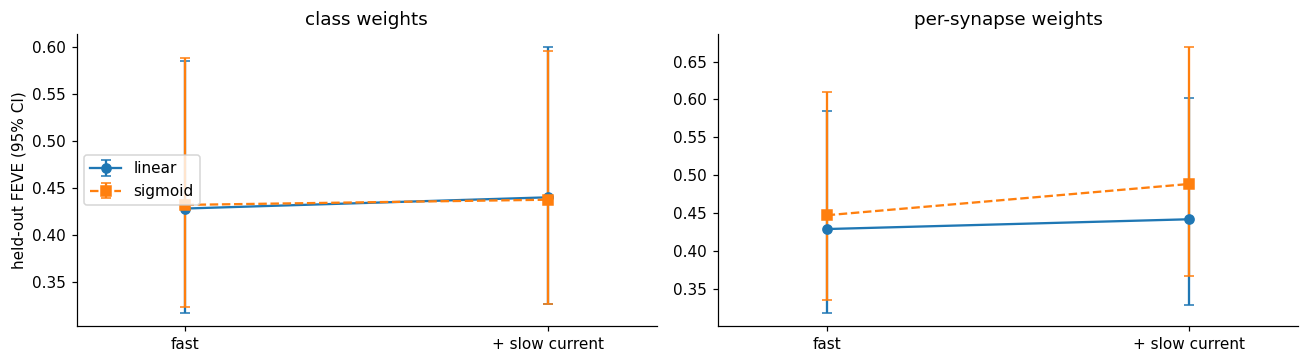

In [5]:
def full_pred(L, p):
    cols = np.arange(ds.S)
    return np.asarray(lad.predict(L, to_jnp(p), st, ds.stim, ds.strains, cfg, cols, proto=lad.proto_cols(ds, cols)))
def cv_from(models, L):
    out = np.zeros(ds.mean.shape)
    for f in range(len(folds)):
        msk = folds[f].reshape(folds[f].shape + (1,) * (ds.mean.ndim - 3))
        out = np.where(msk, full_pred(L, models[f][L]), out)
    return out
if PRED is None:
    PRED = {L: cv_from(QUICK, L) for L in QUICK[0]}
PRED["L0ws"] = cv_from(FITS, "L0ws")
ALL = [L for L in ("L0", "L0s", "L1c", "L1cs", "L0w", "L0ws", "L1", "L1s", "L2", "L3", "L4") if L in PRED]
COUNT = {L: lad.trainable_count(L, st) for L in ALL}
LADDER = tuple(sorted(ALL, key=COUNT.get))
def decide(strain=None):
    point, boots = M_.bootstrap_feve(PRED, ds, list(LADDER) + ["B"], n_boot=N_BOOT, seed=0, strain=strain)
    suff = M_.closure_decision(point, boots, ladder=LADDER, threshold=THRESHOLD, blackbox="B")
    nec = M_.necessity(point, boots, ladder=LADDER)
    v4 = {"delta=0": M_.calibrated_closure(boots, 0.0, LADDER)["L_closed"]}
    v4.update({f"delta[{k}]={d:.3f}": M_.calibrated_closure(boots, d, LADDER)["L_closed"] for k, d in DELTA.items()})
    return dict(point=point, boots=boots, L_star=suff["L_star"], L_needed=nec["L_needed"], v4=v4, nec=nec)
RES = {"both": decide(), "WT": decide("wt")}
per_u = M_.bootstrap_feve(PRED, ds, list(LADDER) + ["B"], n_boot=200, seed=0, strain="unc31")[0] if "unc31" in ds.strains else {}
b, pt = RES["both"]["boots"], RES["both"]["point"]
print("2 x 2 x 2 (held-out FEVE, both strains):")
print(f"{'':10s}{'class/fast':>12s}{'class/slow':>12s}{'syn/fast':>12s}{'syn/slow':>12s}")
for nl in (0, 1):
    print(f"{('linear', 'sigmoid')[nl]:10s}" + "".join(f"{pt[CUBE[(nl, sy, sl)]]:12.3f}" for sy in (0, 1) for sl in (0, 1)))
# factorial effects on every bootstrap draw (+-1 coding; effect = mean(+) - mean(-))
EFF = {}
for order in (1, 2, 3):
    for idx in itertools.combinations(range(3), order):
        sign = {cell: np.prod([1 if cell[i] else -1 for i in idx]) for cell in CUBE}
        draws = sum(sign[cell] * b[L] for cell, L in CUBE.items()) / 4.0
        point_ = sum(sign[cell] * pt[L] for cell, L in CUBE.items()) / 4.0
        lo, hi = np.percentile(draws, [2.5, 97.5])
        EFF[" x ".join(FACTORS[i] for i in idx)] = dict(point=float(point_), ci=[float(lo), float(hi)])
print("\nfactorial effects (FEVE; main effect = mean with - mean without):")
for k, v in EFF.items():
    print(f"  {k:52s} {v['point']:+.4f}  95% CI [{v['ci'][0]:+.4f}, {v['ci'][1]:+.4f}]{'  *' if v['ci'][0] > 0 or v['ci'][1] < 0 else ''}")
SLOW_X_SYNAPSE = bool(EFF["synapse weights x slow current"]["ci"][0] > 0 or EFF["synapse weights x slow current"]["ci"][1] < 0)
d = b["L1s"] - b["L0ws"]; lo, hi = np.percentile(d, [2.5, 97.5])
NONLINEARITY_NEEDED = bool(lo > 0)
print(f"\nL1s - L0ws: {pt['L1s'] - pt['L0ws']:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]")
for x, y in (("L0ws", "L0w"), ("L0ws", "L0s"), ("L0ws", "L0")):
    dd = b[x] - b[y]; l_, h_ = np.percentile(dd, [2.5, 97.5]); print(f"{x} - {y}: {pt[x] - pt[y]:+.4f}  95% CI [{l_:+.4f}, {h_:+.4f}]")
best = max(LADDER, key=lambda L: pt[L])
ok = [L for L in LADDER if L == best or np.percentile(b[L] - b[best], 97.5) >= 0]
MINIMAL = min(ok, key=COUNT.get)
print(f"\n{'rung':5s}{'params':>8s}{'both':>8s}{'WT':>8s}{'unc-31':>8s}")
for L in LADDER + ("B",):
    print(f"{L:5s}{str(COUNT.get(L, '—')):>8s}{pt[L]:8.3f}{RES['WT']['point'][L]:8.3f}{per_u.get(L, np.nan):8.3f}")
print(); print(M_.format_necessity(RES["both"]["nec"]))
for k, r in RES.items():
    print(f"{k:5s}: L* = {r['L_star']} | L_needed = {r['L_needed']} | v4 = {r['v4']}")
OC = {}
for k in ("both", "WT"):
    r = RES[k]; Ls = r["L_star"]
    if Ls is None:
        OC[k] = False; continue
    l_, h_ = np.percentile(r["boots"]["B"] - r["boots"][Ls], [2.5, 97.5]); OC[k] = bool(l_ > THRESHOLD)
print("Registered rules -> NONLINEARITY_NEEDED:", NONLINEARITY_NEEDED, "| SLOW_X_SYNAPSE:", SLOW_X_SYNAPSE, "| MINIMAL:", MINIMAL,
      f"(best: {best}) | CLOSED_FINAL (both / WT):", RES["both"]["L_needed"], "/", RES["WT"]["L_needed"], "| OUTCOME_C:", OC)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
for a_, (sy, title) in zip(ax, ((0, "class weights"), (1, "per-synapse weights"))):
    for nl, mk_ in ((0, "o-"), (1, "s--")):
        ys = [pt[CUBE[(nl, sy, sl)]] for sl in (0, 1)]
        lo_ = [np.percentile(b[CUBE[(nl, sy, sl)]], 2.5) for sl in (0, 1)]; hi_ = [np.percentile(b[CUBE[(nl, sy, sl)]], 97.5) for sl in (0, 1)]
        a_.errorbar([0, 1], ys, yerr=[np.subtract(ys, lo_), np.subtract(hi_, ys)], fmt=mk_, capsize=3, label=("linear", "sigmoid")[nl])
    a_.set_xticks([0, 1]); a_.set_xticklabels(["fast", "+ slow current"]); a_.set_xlim(-0.3, 1.3); a_.set_title(title)
ax[0].set_ylabel("held-out FEVE (95% CI)"); ax[0].legend(); plt.tight_layout(); plt.show()

In [6]:
out = {"source": SOURCE, "cycles": CYC, "free_parameters": COUNT, "ladder": list(LADDER),
       "NONLINEARITY_NEEDED": NONLINEARITY_NEEDED, "SLOW_X_SYNAPSE": SLOW_X_SYNAPSE, "MINIMAL": MINIMAL, "best": best,
       "L1s_minus_L0ws": {"point": float(pt["L1s"] - pt["L0ws"]), "ci": [float(lo), float(hi)]},
       "factorial": EFF, "cube": {"/".join(map(str, k)): {"rung": v, "feve": float(pt[v])} for k, v in CUBE.items()},
       "decisions": {k: {"feve": {L: float(v) for L, v in r["point"].items()}, "L_star": r["L_star"], "L_needed": r["L_needed"], "v4": r["v4"]}
                     for k, r in RES.items()},
       "OUTCOME_C": OC, "feve_unc31": {L: float(v) for L, v in per_u.items()},
       "fits_L0ws": {str(f): INFO[f] for f in range(len(folds))}}
json.dump(out, open(os.path.join(RESULTS, f"E1r_result{TAG}.json"), "w"), indent=2, default=float)
np.savez_compressed(os.path.join(RESULTS, f"E1r_heldout_predictions{TAG}.npz"), L0ws=PRED["L0ws"])
print("saved", f"E1r_result{TAG}.json and E1r_heldout_predictions{TAG}.npz")

saved E1r_result_laptop.json and E1r_heldout_predictions_laptop.npz


## 3 · Reading the result

| NONLINEARITY_NEEDED | reading for C2 (E1, final) |
|---|---|
| no (`L0ws` ≈ L1s) | **The closed level is a linear network on the connectome with measured synaptic weights and one slow process.** The sigmoid is not needed. Whatever L1s gains over the wiring model comes from per-synapse weights *and* a slow current acting together (SLOW_X_SYNAPSE). The "software" of single-neuron stimulation is linear, but it is not readable from anatomy alone: each synapse's strength must be measured, and the neurons carry a slow process (seconds). |
| yes (L1s > `L0ws`) | **All three ingredients are needed:** nonlinear neurons, measured synaptic weights and a slow process. The closed level is L1s, E1's first rung plus one slow current (2 numbers). |

MINIMAL names the simplest description the data cannot tell apart from the best. CLOSED_FINAL is what E1's pre-registered rules say; they agree when the necessity table has a single deepest needed rung.

**What E1 leaves open.**
* Which *biological* slow process this is. L2 (adaptation), L3 (peptides) and L4 (homeostasis) all capture part of it, but none beats one global slow current. Time-resolved stimulation, Notebook 08's design, could separate them.
* The `full`-mode run (300 neurons, GPU).
* Whether the same holds in a second nervous system (Drosophila, Notebook 34).